
#  First Passage Times of Ornstein–Uhlenbeck processes to moving boundaries: Theory vs Monte Carlo

This notebook builds a full numerical experiment for the first-passage time (FPT) of a driftless Ornstein–Uhlenbeck (OU) process to:

1. a **constant barrier** $$f(t)=a,$$
2. a **transformed barrier** $$S^{k}_{\alpha,\beta}f,$$

using the identities developed in your paper.

The workflow is:

- define the OU model and the time-change functions $r(t)$ and $s(u)$,
- numerically evaluate the **explicit theoretical density** for the constant barrier from Example 3.3,
- simulate many OU paths and estimate the **Monte Carlo FPT density**,
- compare theory and simulation,
- apply the transformation $S^{k}_{\alpha,\beta}$,
- derive the transformed theoretical density from Theorem 3.1,
- compare theory and simulation again for the transformed barrier.

---

## Mathematical setup

We work with the OU process

$$
dU_t=-kU_t\,dt+dB_t, \qquad U_0=0,
$$

with $k>0$. The key time-change functions are

$$
r(t)=\frac{e^{2kt}-1}{2k},
\qquad
s(u)=\frac{\log(1+2ku)}{2k}.
$$

For a boundary $f$, define the first-passage time

$$
T_k^f=\inf\{t>0:U_t=f(t)\}.
$$

For a constant boundary, Example 3.3 gives an explicit density of $T_k^a$ as a series involving parabolic cylinder functions.

The transformed boundary is

$$
S_{\alpha,\beta}^k f(t)
=
\left(\frac{1+\alpha\beta r(t)}{\alpha}\right)
\left(1+\frac{2k\alpha^2 r(t)}{1+\alpha\beta r(t)}\right)^{1/2}
e^{-kt}
f\!\left(
s\!\left(\frac{\alpha^2 r(t)}{1+\alpha\beta r(t)}\right)
\right).
$$

For a constant barrier $$f(t)=a,$$ this simplifies because the time argument of $f$ disappears.

---

## Numerical remarks

This notebook uses three different kinds of approximation:

1. **Series truncation** for the explicit density.
2. **Numerical root-finding** for the zeros in the index variable $\nu\mapsto D_\nu(b)$.
3. **Finite differences in $\nu$** to approximate $\partial D_\nu(b)/\partial \nu$.

The Monte Carlo part simulates OU sample paths using the **exact Gaussian OU transition**, not Euler–Maruyama. The goal is to study how well the approximations line up.


In [33]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import pbdv, gamma
from scipy.optimize import root_scalar
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid, trapezoid

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


## 1. OU time-change functions and transformed barrier

We first define the basic deterministic functions $r(t)$, $s(u)$, and the transformed barrier $S_{\alpha,\beta}^k f$.

For the constant barrier $$f(t)=a,$$ the transformed barrier becomes

$$
S_{\alpha,\beta}^k a(t)
=
a\left(\frac{1+\alpha\beta r(t)}{\alpha}\right)
\left(1+\frac{2k\alpha^2 r(t)}{1+\alpha\beta r(t)}\right)^{1/2}
e^{-kt}.
$$


In [34]:
def r_of_t(t, k):
    t = np.asarray(t)
    return (np.exp(2.0 * k * t) - 1.0) / (2.0 * k)

def s_of_u(u, k):
    u = np.asarray(u)
    return np.log(1.0 + 2.0 * k * u) / (2.0 * k)

def constant_barrier(t, a):
    t = np.asarray(t)
    return a + 0.0 * t

def transformed_constant_barrier(t, a, k, alpha, beta):
    t = np.asarray(t)
    rt = r_of_t(t, k)
    return (
        a
        * ((1.0 + alpha * beta * rt) / alpha)
        * np.sqrt(1.0 + (2.0 * k * alpha**2 * rt) / (1.0 + alpha * beta * rt))
        * np.exp(-k * t)
    )


## 2. Parabolic cylinder function machinery

The constant-barrier explicit density in Example 3.3 involves the parabolic cylinder function $D_\nu(x)$, evaluated at

- $$x=0,$$
- $$x=b=-a\sqrt{2k},$$

together with

- zeros of the function $$\nu \mapsto D_\nu(b),$$
- the derivative $$\partial D_\nu(b)/\partial \nu.$$

### Important implementation detail

SciPy's `pbdv(v, x)` returns
$$D_v(x),$$
and the derivative with respect to **$x$**, not with respect to the index $v$. So to approximate $$\partial D_\nu(b)/\partial \nu,$$ we use a finite difference in $\nu$.


In [35]:
def D_nu_x(nu, x):
    # SciPy returns (D_v(x), d/dx D_v(x))
    val, _ = pbdv(nu, x)
    return val

def dD_dnu(nu, x, h=1e-5):
    return (D_nu_x(nu + h, x) - D_nu_x(nu - h, x)) / (2.0 * h)

def D_nu_0(nu):
    # Identity for D_nu(0)
    return 2.0**(nu / 2.0) * np.sqrt(np.pi) / gamma((1.0 - nu) / 2.0)


## 3. Root-finding for the zeros $\nu_{j,b}$

The series formula for the constant-barrier density uses the zeros $\nu_{j,b}$ of

$$
\nu \mapsto D_\nu(b), \qquad b=-a\sqrt{2k}.
$$

We find them numerically by

1. scanning a grid in $\nu$,
2. looking for sign changes,
3. refining each bracket with Brent's method.

In [36]:
def find_nu_roots(b, n_roots=20, nu_min=0.01, nu_max=120.0, step=0.05, verbose=False):
    grid = np.arange(nu_min, nu_max + step, step)
    vals = np.array([D_nu_x(nu, b) for nu in grid], dtype=float)

    roots = []
    for i in range(len(grid) - 1):
        if len(roots) >= n_roots:
            break

        f1 = vals[i]
        f2 = vals[i + 1]
        if np.isnan(f1) or np.isnan(f2):
            continue

        if f1 == 0:
            roots.append(grid[i])
        elif f1 * f2 < 0:
            left, right = grid[i], grid[i + 1]
            sol = root_scalar(lambda nu: D_nu_x(nu, b), bracket=[left, right], method="brentq")
            roots.append(sol.root)

    roots = np.array(roots)
    if verbose:
        print(f"Found {len(roots)} roots")
        print(roots)
    return roots


## 4. Explicit theoretical density for the constant barrier

We now implement the series formula from Example 3.3.

The density is approximated by truncating the infinite sum at $J$ roots:

$$
p_k^a(t)
\approx
-k e^{-ka^2/2}
\sum_{j=1}^{J}
\frac{D_{\nu_{j,b}}(0)}
{\left.\frac{\partial}{\partial \nu}D_\nu(b)\right|_{\nu=\nu_{j,b}}}
e^{-k\nu_{j,b} t},
\qquad
b=-a\sqrt{2k}.
$$

Because this is a numerical approximation, it is worth checking

- positivity of the density,
- how sensitive results are to the number of roots $J$,
- whether the resulting density integrates reasonably over the chosen time horizon.


In [37]:
def constant_barrier_density_series(t, a, k, roots, fd_step=1e-5):
    t = np.asarray(t, dtype=float)
    b = -a * np.sqrt(2.0 * k)
    pref = -k * np.exp(-k * a * a / 2.0)

    total = np.zeros_like(t, dtype=float)
    for nu in roots:
        numerator = D_nu_0(nu)
        denominator = dD_dnu(nu, b, h=fd_step)
        total += (numerator / denominator) * np.exp(-k * nu * t)

    return pref * total

def density_to_cdf(t_grid, density):
    density = np.maximum(density, 0.0)
    cdf = cumulative_trapezoid(density, t_grid, initial=0.0)
    return np.clip(cdf, 0.0, 1.0)


## 5. Monte Carlo simulation of OU first-passage times

We simulate the OU process using its exact one-step transition:

$$
U_{t+\Delta}
=
e^{-k\Delta}U_t
+
\sqrt{\frac{1-e^{-2k\Delta}}{2k}}\,Z,
\qquad Z\sim N(0,1).
$$

This is better than Euler–Maruyama for OU, because the transition law is known exactly.

### Crossing detection

For each simulated path we record the first grid time where the path crosses the barrier. This is still a discretisation approximation, because crossings between grid points can be missed.
Reducing `dt` improves this.


In [39]:
def simulate_ou_fpt(barrier_func, k, dt=1e-3, t_max=8.0, n_paths=50000, seed=123):
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(t_max / dt))

    x = np.zeros(n_paths)
    alive = np.ones(n_paths, dtype=bool)
    hit_times = np.full(n_paths, np.nan)

    decay = np.exp(-k * dt)
    sd = np.sqrt((1.0 - np.exp(-2.0 * k * dt)) / (2.0 * k))

    prev_t = 0.0
    prev_bar = barrier_func(prev_t)

    for m in range(1, n_steps + 1):
        t = m * dt
        current_bar = barrier_func(t)

        idx_alive = np.where(alive)[0]
        if len(idx_alive) == 0:
            break

        x_prev = x[idx_alive].copy()
        z = rng.normal(size=len(idx_alive))
        x_new = decay * x_prev + sd * z

        # simple discrete crossing test
        crossed = (x_prev < prev_bar) & (x_new >= current_bar)

        # linear interpolation for crossing time
        if np.any(crossed):
            numer = prev_bar - x_prev[crossed]
            denom = (x_new[crossed] - x_prev[crossed]) - (current_bar - prev_bar)
            frac = np.where(np.abs(denom) > 1e-12, numer / denom, 0.5)
            frac = np.clip(frac, 0.0, 1.0)

            crossed_idx = idx_alive[crossed]
            hit_times[crossed_idx] = prev_t + frac * dt
            alive[crossed_idx] = False

        x[idx_alive] = x_new
        prev_t = t
        prev_bar = current_bar

    return hit_times[~np.isnan(hit_times)]


## 6. Monte Carlo density and CDF on the unconditional scale

A subtle but important point is that if we compute a Kernel Density Estimation (KDE) from the observed hit times only, then the KDE integrates to **1 over the observed hits**.

That is a **conditional** density, namely the density of the hit time given that a hit was observed before the simulation horizon.

But the theoretical first-passage-time density is an **unconditional** density.  
So for a fair comparison, the Monte Carlo density must be scaled by the empirical hit fraction

$$
\widehat p_{\mathrm{hit}}=\frac{\#\{\text{hits by }t_{\max}\}}{n_{\text{paths}}}.
$$

Similarly, the empirical CDF should divide by the total number of simulated paths, not just by the number of observed hits.

This is especially important for transformed boundaries, where the probability of hitting by the finite horizon can be noticeably below 1.


In [40]:
def unconditional_kde_on_grid(samples, t_grid, total_n_paths, bw_method="scott"):
    samples = np.asarray(samples)
    if len(samples) == 0:
        return np.zeros_like(t_grid, dtype=float)

    kde = gaussian_kde(samples, bw_method=bw_method)
    vals = kde(t_grid)
    vals[vals < 0] = 0.0

    hit_fraction = len(samples) / total_n_paths
    return hit_fraction * vals

def unconditional_empirical_cdf_on_grid(samples, t_grid, total_n_paths):
    samples = np.sort(np.asarray(samples))
    return np.searchsorted(samples, t_grid, side="right") / total_n_paths


## 7. Parameters for the experiment

You can change these parameters and rerun the notebook.

Suggested first values:

- moderate mean reversion $k$,
- a positive constant barrier $a$,
- around 15–25 roots for the theoretical series,
- a reasonably fine simulation step `dt`.


In [41]:
# Main parameters
k = 0.5
a = 1.0

alpha = 1.4
beta = 0.6

# Numerical parameters
n_roots = 20
fd_step = 1e-5

# Monte Carlo parameters
dt = 1e-3
t_max = 8.0
n_paths = 50000
seed_const = 123
seed_trans = 456

# Theory evaluation grid
t_grid = np.linspace(1e-4, t_max, 1000)


## 8. Find the required roots for the constant-barrier density

For the constant barrier case, the roots depend on

$$
b=-a\sqrt{2k}.
$$


In [42]:
b = -a * np.sqrt(2.0 * k)
roots = find_nu_roots(b, n_roots=n_roots, nu_min=0.01, nu_max=150.0, step=0.05, verbose=True)
roots

Found 20 roots
[ 0.38823829  2.          3.70306994  5.4546093   7.23689663  9.04082696
 10.86103193 12.69404244 14.53746659 16.38957378 18.24906455 20.11493394
 21.98638589 23.86277714 25.74357909 27.62835113 29.51672142 31.40837274
 33.30303187 35.20046153]


array([ 0.38823829,  2.        ,  3.70306994,  5.4546093 ,  7.23689663,
        9.04082696, 10.86103193, 12.69404244, 14.53746659, 16.38957378,
       18.24906455, 20.11493394, 21.98638589, 23.86277714, 25.74357909,
       27.62835113, 29.51672142, 31.40837274, 33.30303187, 35.20046153])


## 9. Evaluate the explicit theoretical density for the constant barrier

We now compute

- the approximate density $p_k^a(t),$
- the approximate CDF by numerical integration.


In [43]:
theory_density_const = constant_barrier_density_series(t_grid, a, k, roots, fd_step=fd_step)
theory_density_const = np.maximum(theory_density_const, 0.0)

theory_cdf_const = density_to_cdf(t_grid, theory_density_const)

print("Approximate integral of density over grid:", trapezoid(theory_density_const, t_grid))
print("Final CDF value on grid:", theory_cdf_const[-1])

Approximate integral of density over grid: 0.8319959462880465
Final CDF value on grid: 0.8319959462880494



## 10. Plot the theoretical density for the constant barrier

This lets us inspect whether the numerical approximation looks sensible before comparing it to Monte Carlo.


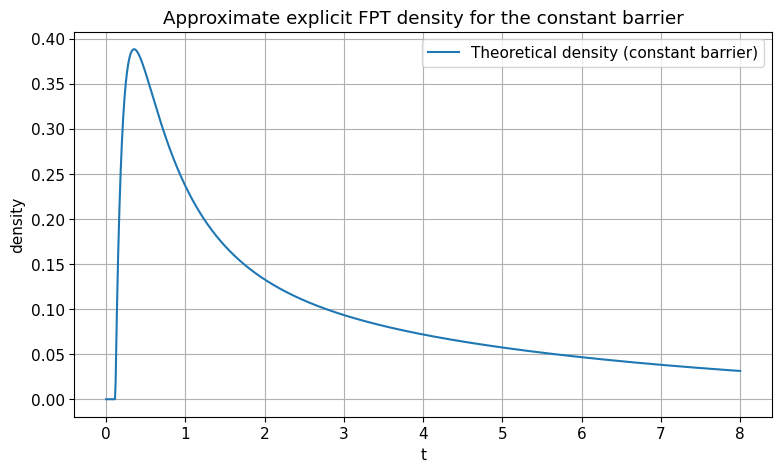

In [44]:
plt.figure()
plt.plot(t_grid, theory_density_const, label="Theoretical density (constant barrier)")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Approximate explicit FPT density for the constant barrier")
plt.legend()
plt.show()


## 11. Monte Carlo simulation for the constant barrier

We simulate many OU sample paths and record their first-passage times to the constant barrier $a$.


In [45]:
barrier_const = lambda t: constant_barrier(t, a)

hits_const = simulate_ou_fpt(
    barrier_func=barrier_const,
    k=k,
    dt=dt,
    t_max=t_max,
    n_paths=n_paths,
    seed=seed_const,
)

print("Number of hits observed:", len(hits_const))
print("Estimated hit probability by time horizon:", len(hits_const) / n_paths)
print("Mean observed hit time (conditional on hit):", np.mean(hits_const))

Number of hits observed: 41696
Estimated hit probability by time horizon: 0.83392
Mean observed hit time (conditional on hit): 2.5103721758816073



## 12. Compare theoretical density and Monte Carlo density for the constant barrier


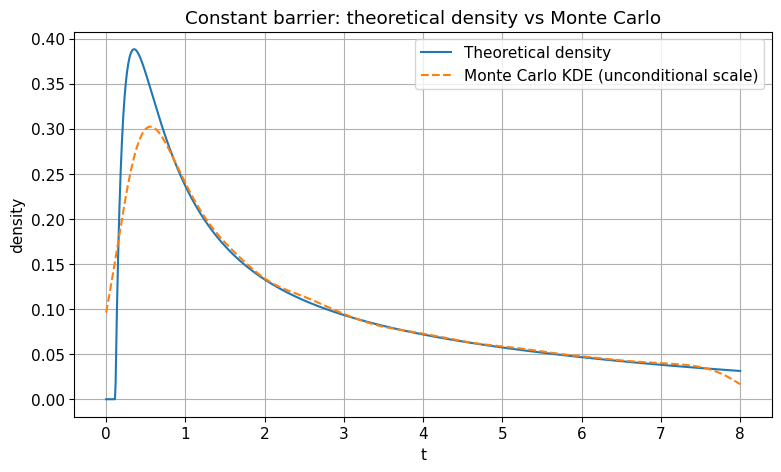

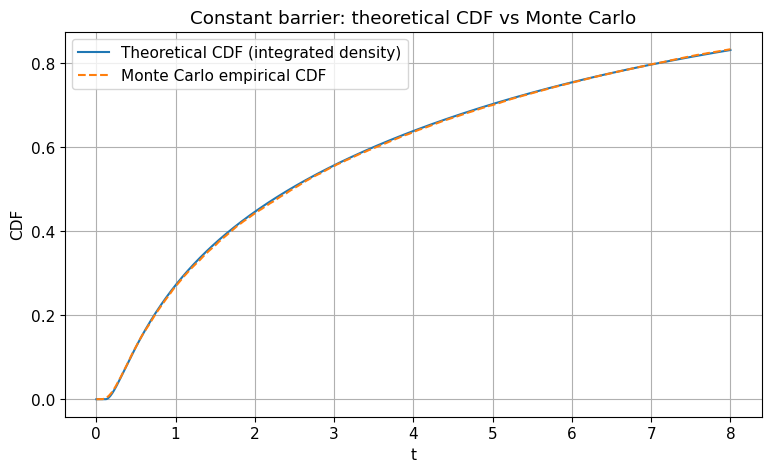

Empirical hit fraction by t_max (constant): 0.83392
Integral of theoretical density on [0, t_max] (constant): 0.8319959462880465


In [46]:
mc_density_const = unconditional_kde_on_grid(hits_const, t_grid, n_paths)
mc_cdf_const = unconditional_empirical_cdf_on_grid(hits_const, t_grid, n_paths)

plt.figure()
plt.plot(t_grid, theory_density_const, label="Theoretical density")
plt.plot(t_grid, mc_density_const, linestyle="--", label="Monte Carlo KDE (unconditional scale)")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Constant barrier: theoretical density vs Monte Carlo")
plt.legend()
plt.show()

plt.figure()
plt.plot(t_grid, theory_cdf_const, label="Theoretical CDF (integrated density)")
plt.plot(t_grid, mc_cdf_const, linestyle="--", label="Monte Carlo empirical CDF")
plt.xlabel("t")
plt.ylabel("CDF")
plt.title("Constant barrier: theoretical CDF vs Monte Carlo")
plt.legend()
plt.show()

print("Empirical hit fraction by t_max (constant):", len(hits_const) / n_paths)
print("Integral of theoretical density on [0, t_max] (constant):", trapezoid(theory_density_const, t_grid))



## 13. Visualise some OU paths against the constant barrier

This is mainly for intuition.


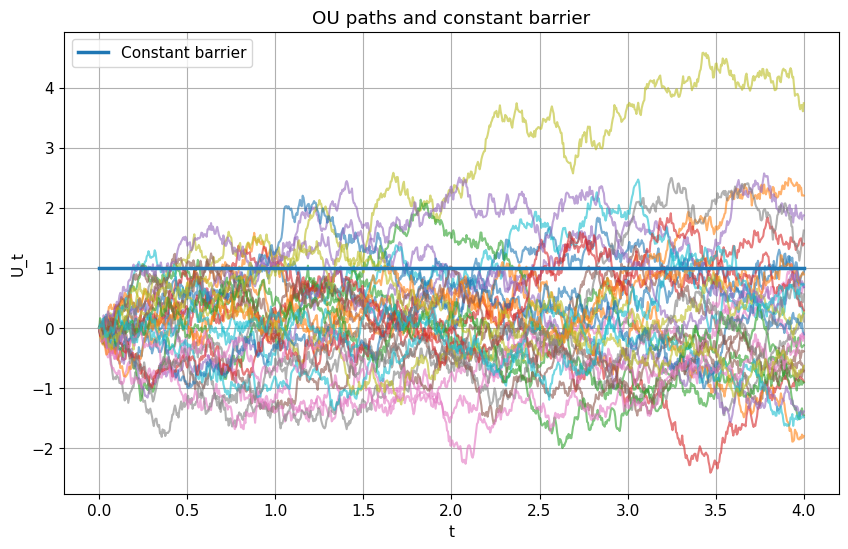

In [47]:
def simulate_ou_paths(k, dt, t_max, n_paths=30, seed=0):
    rng = np.random.default_rng(seed)
    n_steps = int(np.ceil(t_max / dt))
    times = np.linspace(0.0, n_steps * dt, n_steps + 1)

    paths = np.zeros((n_paths, n_steps + 1))
    decay = np.exp(-k * dt)
    sd = np.sqrt((1.0 - np.exp(-2.0 * k * dt)) / (2.0 * k))

    for i in range(n_steps):
        z = rng.normal(size=n_paths)
        paths[:, i + 1] = decay * paths[:, i] + sd * z

    return times, paths

times_vis, paths_vis = simulate_ou_paths(k, dt=5e-3, t_max=min(t_max, 4.0), n_paths=30, seed=777)
bar_vis_const = constant_barrier(times_vis, a)

plt.figure(figsize=(10, 6))
for i in range(paths_vis.shape[0]):
    plt.plot(times_vis, paths_vis[i], alpha=0.6)
plt.plot(times_vis, bar_vis_const, linewidth=2.5, label="Constant barrier")
plt.xlabel("t")
plt.ylabel("U_t")
plt.title("OU paths and constant barrier")
plt.legend()
plt.show()


## 14. Build the transformed barrier $S_{\alpha,\beta}^k a$

Now we apply the two-parameter transformation from the paper. This gives a new explicit moving boundary, starting from the constant barrier.


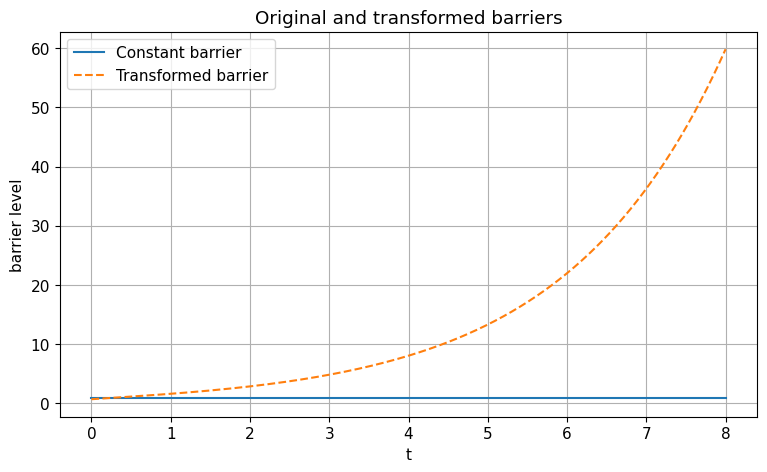

In [48]:
barrier_trans = lambda t: transformed_constant_barrier(t, a, k, alpha, beta)

barrier_const_vals = barrier_const(t_grid)
barrier_trans_vals = barrier_trans(t_grid)

plt.figure()
plt.plot(t_grid, barrier_const_vals, label="Constant barrier")
plt.plot(t_grid, barrier_trans_vals, linestyle="--", label="Transformed barrier")
plt.xlabel("t")
plt.ylabel("barrier level")
plt.title("Original and transformed barriers")
plt.legend()
plt.show()


## 15. The transformed theoretical density from Theorem 3.1

The theorem expresses the transformed density in terms of

- a deterministic prefactor,
- the original density evaluated at $s\!\left(\frac{\alpha^2 r(t)}{1+\alpha\beta r(t)}\right).$

Here we implement the transformed density in the form

$$
p_k^{S_{\alpha,\beta}^k f}(t)
=
e^{2kt}\alpha^2(1+\alpha\beta r(t))^{-3/2}
\left(1+\frac{2k\alpha^2 r(t)}{1+\alpha\beta r(t)}\right)^{-1}
\exp\!\left(
-\frac{\alpha\beta}{2(1+\alpha\beta r(t))}
\bigl(S_{\alpha,\beta}^k f(t)\bigr)^2 e^{2kt}
\right)
\,p_k^f\!\left(
s\!\left(\frac{\alpha^2 r(t)}{1+\alpha\beta r(t)}\right)
\right).
$$

This is the version that should be compared directly with Monte Carlo.


In [49]:
def transformed_density_from_theorem(t, a, k, alpha, beta, roots, fd_step=1e-5):
    t = np.asarray(t, dtype=float)
    rt = r_of_t(t, k)

    inner_u = alpha**2 * rt / (1.0 + alpha * beta * rt)
    inner_t = s_of_u(inner_u, k)

    S_val = transformed_constant_barrier(t, a, k, alpha, beta)

    # Correct prefactor from the theorem when multiplied directly by the base density.
    pref = (
        np.exp(2.0 * k * t)
        * alpha**2
        * (1.0 + alpha * beta * rt) ** (-1.5)
        * (1.0 + (2.0 * k * alpha**2 * rt) / (1.0 + alpha * beta * rt)) ** (-1.0)
        * np.exp(
            -alpha * beta * (S_val**2) * np.exp(2.0 * k * t)
            / (2.0 * (1.0 + alpha * beta * rt))
        )
    )

    base_density = constant_barrier_density_series(inner_t, a, k, roots, fd_step=fd_step)
    return pref * base_density


## 16. Evaluate the transformed theoretical density


In [50]:
theory_density_trans = transformed_density_from_theorem(
    t_grid, a, k, alpha, beta, roots, fd_step=fd_step
)
theory_density_trans = np.maximum(theory_density_trans, 0.0)

theory_cdf_trans = density_to_cdf(t_grid, theory_density_trans)

print("Approximate integral of transformed density over grid:", trapezoid(theory_density_trans, t_grid))
print("Final transformed CDF value on grid:", theory_cdf_trans[-1])

Approximate integral of transformed density over grid: 0.18010698296248961
Final transformed CDF value on grid: 0.18010698296248964



## 17. Plot the transformed theoretical density


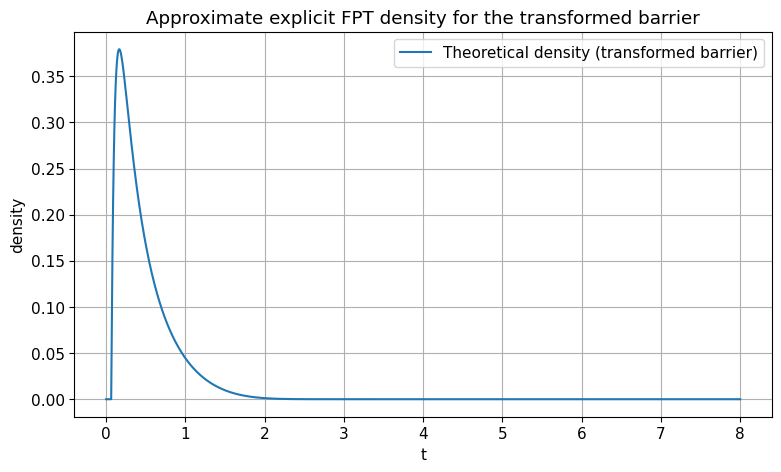

In [51]:
plt.figure()
plt.plot(t_grid, theory_density_trans, label="Theoretical density (transformed barrier)")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Approximate explicit FPT density for the transformed barrier")
plt.legend()
plt.show()


## 18. Monte Carlo simulation for the transformed barrier


In [52]:
hits_trans = simulate_ou_fpt(
    barrier_func=barrier_trans,
    k=k,
    dt=dt,
    t_max=t_max,
    n_paths=n_paths,
    seed=seed_trans,
)

print("Number of hits observed:", len(hits_trans))
print("Estimated hit probability by time horizon:", len(hits_trans) / n_paths)
print("Mean observed hit time (conditional on hit):", np.mean(hits_trans))

Number of hits observed: 8807
Estimated hit probability by time horizon: 0.17614
Mean observed hit time (conditional on hit): 0.44934066615504326



## 19. Compare theoretical density and Monte Carlo density for the transformed barrier


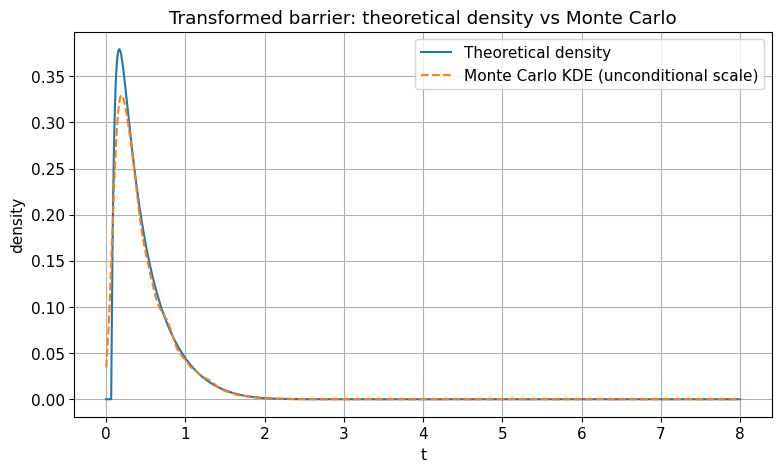

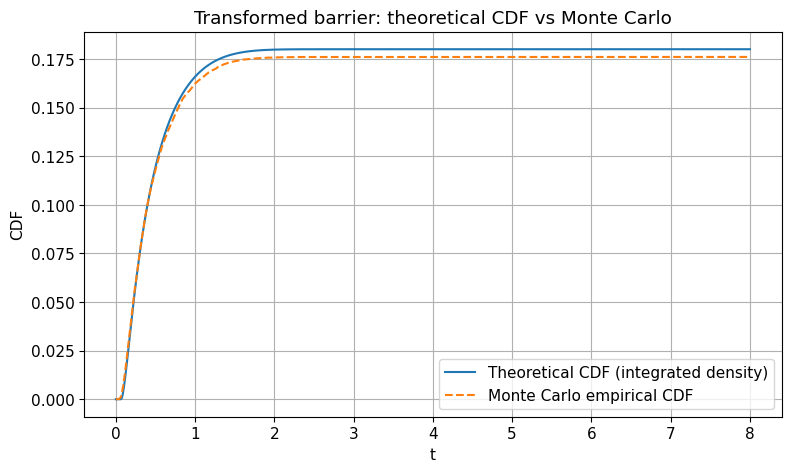

Empirical hit fraction by t_max (transformed): 0.17614
Integral of theoretical density on [0, t_max] (transformed): 0.18010698296248961


In [53]:
mc_density_trans = unconditional_kde_on_grid(hits_trans, t_grid, n_paths)
mc_cdf_trans = unconditional_empirical_cdf_on_grid(hits_trans, t_grid, n_paths)

plt.figure()
plt.plot(t_grid, theory_density_trans, label="Theoretical density")
plt.plot(t_grid, mc_density_trans, linestyle="--", label="Monte Carlo KDE (unconditional scale)")
plt.xlabel("t")
plt.ylabel("density")
plt.title("Transformed barrier: theoretical density vs Monte Carlo")
plt.legend()
plt.show()

plt.figure()
plt.plot(t_grid, theory_cdf_trans, label="Theoretical CDF (integrated density)")
plt.plot(t_grid, mc_cdf_trans, linestyle="--", label="Monte Carlo empirical CDF")
plt.xlabel("t")
plt.ylabel("CDF")
plt.title("Transformed barrier: theoretical CDF vs Monte Carlo")
plt.legend()
plt.show()

print("Empirical hit fraction by t_max (transformed):", len(hits_trans) / n_paths)
print("Integral of theoretical density on [0, t_max] (transformed):", trapezoid(theory_density_trans, t_grid))


## 20. Visualise some OU paths against the transformed barrier


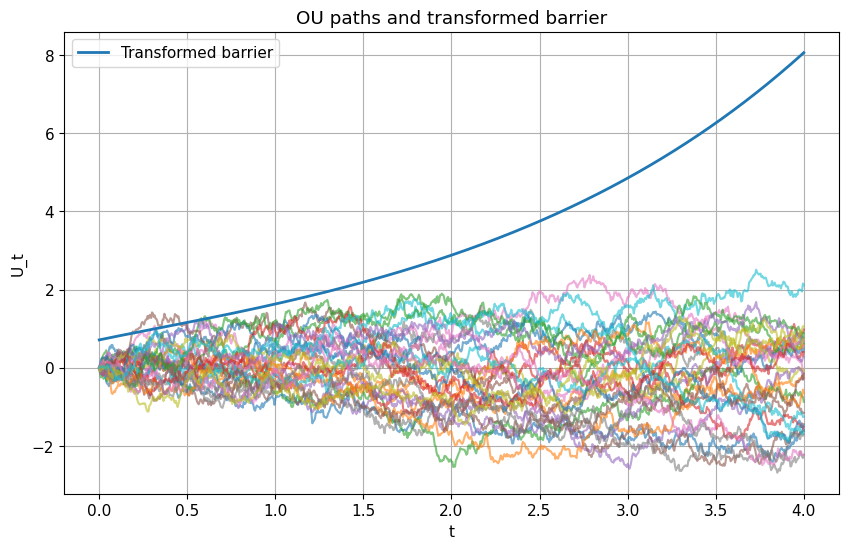

In [54]:
times_vis2, paths_vis2 = simulate_ou_paths(k, dt=5e-3, t_max=min(t_max, 4.0), n_paths=30, seed=999)
bar_vis_trans = barrier_trans(times_vis2)

plt.figure(figsize=(10, 6))
for i in range(paths_vis2.shape[0]):
    plt.plot(times_vis2, paths_vis2[i], alpha=0.6)
plt.plot(times_vis2, bar_vis_trans, linewidth=2, label="Transformed barrier")
plt.xlabel("t")
plt.ylabel("U_t")
plt.title("OU paths and transformed barrier")
plt.legend()
plt.show()


## 21. A small quantitative summary

This cell gives a compact summary of the numerical comparison.

You can use this when discussing the notebook in a report or presentation.


In [55]:

summary = {
    "constant_barrier_density_integral": float(trapezoid(theory_density_const, t_grid)),
    "constant_barrier_mc_hit_prob": float(len(hits_const) / n_paths),
    "transformed_barrier_density_integral": float(trapezoid(theory_density_trans, t_grid)),
    "transformed_barrier_mc_hit_prob": float(len(hits_trans) / n_paths),
    "constant_barrier_mc_mean_hit_time": float(np.mean(hits_const)) if len(hits_const) else np.nan,
    "transformed_barrier_mc_mean_hit_time": float(np.mean(hits_trans)) if len(hits_trans) else np.nan,
    "number_of_roots_used": int(len(roots)),
}

summary

{'constant_barrier_density_integral': 0.8319959462880465,
 'constant_barrier_mc_hit_prob': 0.83392,
 'transformed_barrier_density_integral': 0.18010698296248961,
 'transformed_barrier_mc_hit_prob': 0.17614,
 'constant_barrier_mc_mean_hit_time': 2.5103721758816073,
 'transformed_barrier_mc_mean_hit_time': 0.44934066615504326,
 'number_of_roots_used': 20}


## 22. Interpretation 

A clean way to narrate the numerical results is the following.

### Constant barrier

First, start from the explicit density for the constant barrier and compare it to the Monte Carlo estimate. If the two line up well, that gives numerical evidence that the explicit formula is being evaluated correctly and that the simulation error is under control.

### Transformed barrier

Next, apply the transformation $S_{\alpha,\beta}^k$ to construct a nontrivial moving boundary. Then use Theorem 3.1 to produce the transformed theoretical density from the constant-barrier density. If this again lines up with Monte Carlo, it supports the transformation identity in practice.

### Numerical caveats

Any mismatch between theory and Monte Carlo can come from several sources:

- truncation of the infinite series,
- imperfect root-finding in $\nu$,
- finite-difference error in approximating $\partial D_\nu(b)/\partial \nu$,
- discrete-time bias in the Monte Carlo crossing rule.

So it is useful to test sensitivity with respect to

- `n_roots`,
- `fd_step`,
- `dt`,
- `n_paths`.

### Overall takeaway


1. the explicit constant-barrier density can be evaluated numerically,
2. Monte Carlo agrees well with the theoretical density,
3. the transformed-barrier density obtained through the paper's mapping also agrees with simulation,
4. therefore the theoretical identities are not only formal but also numerically visible.